# Twitter Sentiment Analysis: Exploratory Data Analysis 📊

## 1. Data Exploration
We visualize the class balance and analyze text patterns in our sentiment-labeled tweets.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add project root to path
sys.path.append(os.path.abspath(".."))
from src.data_loader import download_data, load_data
from src.preprocess import clean_tweet


In [2]:

path = download_data()
df = load_data(path)

# For EDA, sample 20,000 tweets
df_sample = df.sample(20000, random_state=42).reset_index(drop=True)

# Sentiment Mapping: 0 -> Negative, 2 -> Neutral (if any), 4 -> Positive
df_sample['sentiment'] = df_sample['target'].map({0: 'Negative', 2: 'Neutral', 4: 'Positive'})

print(f"Sample size: {len(df_sample)}")
df_sample.head()


  0%|          | 0.00/80.9M [00:00<?, ?B/s]

  2%|▏         | 2.00M/80.9M [00:00<00:06, 13.0MB/s]

  5%|▍         | 4.00M/80.9M [00:00<00:05, 15.0MB/s]

  7%|▋         | 6.00M/80.9M [00:00<00:04, 17.0MB/s]

 10%|▉         | 8.00M/80.9M [00:00<00:04, 18.0MB/s]

...

100%|██████████| 80.9M/80.9M [00:04<00:00, 18.2MB/s]

Extracting files...


Dataset path: C:\Users\thoma\.cache\kagglehub\datasets\kazanova\sentiment140\versions\2


Sample size: 20000


,target,ids,date,flag,user,text,sentiment
0,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!,Negative
1,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo...",Negative
2,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...,Negative
3,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...,Negative
4,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem,Negative


C:\Users\thoma\AppData\Local\Temp\ipykernel_7192\746109729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df_sample, palette='viridis')


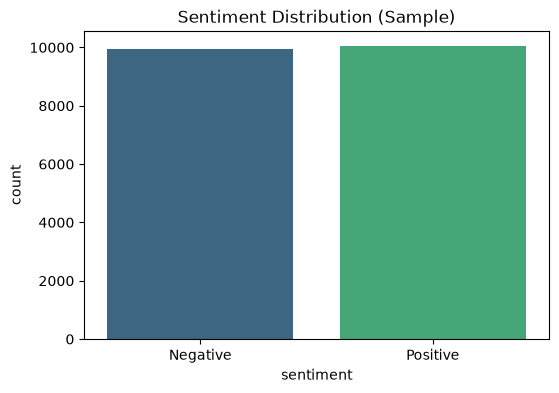

In [3]:

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df_sample, palette='viridis')
plt.title('Sentiment Distribution (Sample)')
plt.show()


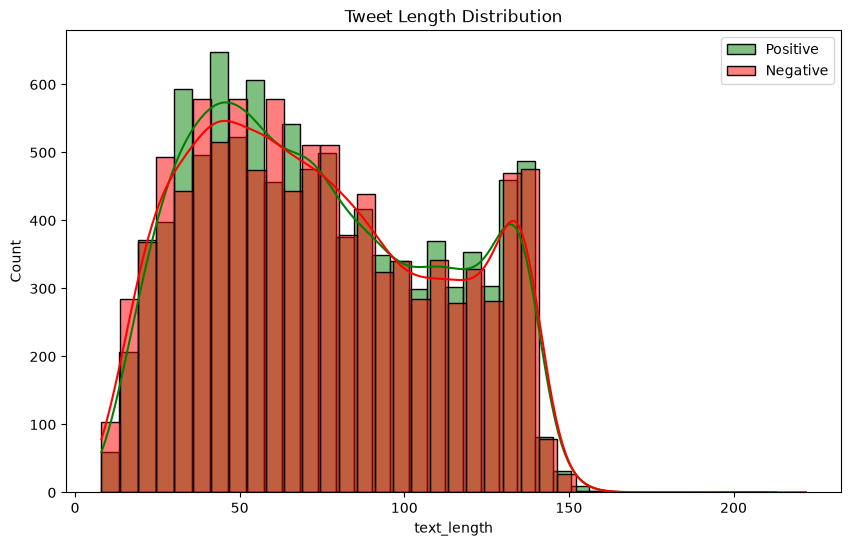

In [4]:

df_sample['text_length'] = df_sample['text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df_sample[df_sample['sentiment']=='Positive']['text_length'], color='green', label='Positive', kde=True)
sns.histplot(df_sample[df_sample['sentiment']=='Negative']['text_length'], color='red', label='Negative', kde=True)
plt.title('Tweet Length Distribution')
plt.legend()
plt.show()
